In [15]:
import os
import tarfile
import shutil
import random
import urllib.request
from pathlib import Path

import h5py
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "svhn_raw"
YOLO_DIR = DATA_DIR / "svhn_yolo"

RAW_DIR.mkdir(parents=True, exist_ok=True)
YOLO_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_URL = "http://ufldl.stanford.edu/housenumbers/train.tar.gz"
TEST_URL = "http://ufldl.stanford.edu/housenumbers/test.tar.gz"

TRAIN_ARCHIVE = RAW_DIR / "train.tar.gz"
TEST_ARCHIVE = RAW_DIR / "test.tar.gz"

TRAIN_DIR = RAW_DIR / "train"
TEST_DIR = RAW_DIR / "test"

In [18]:
def download_file(url, dst):
    if dst.exists():
        return
    urllib.request.urlretrieve(url, dst)

def extract_tar(archive_path, extract_to):
    target_dir = extract_to / archive_path.stem.replace(".tar", "")
    if target_dir.exists():
        return
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_to)

download_file(TRAIN_URL, TRAIN_ARCHIVE)
download_file(TEST_URL, TEST_ARCHIVE)

extract_tar(TRAIN_ARCHIVE, RAW_DIR)
extract_tar(TEST_ARCHIVE, RAW_DIR)

print(TRAIN_DIR)
print(TEST_DIR)

c:\Users\artem\Downloads\cv lab\data\svhn_raw\train
c:\Users\artem\Downloads\cv lab\data\svhn_raw\test


In [19]:
def read_string(f, ref):
    data = f[ref][()]
    return "".join(chr(x[0]) for x in data)

def read_bbox_values(f, bbox_ref, field):
    values_ref = f[bbox_ref][field]
    values = []

    if len(values_ref) > 1:
        for i in range(len(values_ref)):
            ref = values_ref[i][0]
            value = f[ref][()][0][0]
            values.append(float(value))
    else:
        values.append(float(values_ref[0][0]))

    return values

def parse_digit_struct(mat_path):
    result = []

    with h5py.File(mat_path, "r") as f:
        names = f["digitStruct"]["name"]
        bboxes = f["digitStruct"]["bbox"]

        for i in tqdm(range(len(names)), desc=f"Парсинг {mat_path.parent.name}"):
            name_ref = names[i][0]
            bbox_ref = bboxes[i][0]

            filename = read_string(f, name_ref)
            lefts = read_bbox_values(f, bbox_ref, "left")
            tops = read_bbox_values(f, bbox_ref, "top")
            widths = read_bbox_values(f, bbox_ref, "width")
            heights = read_bbox_values(f, bbox_ref, "height")
            labels = read_bbox_values(f, bbox_ref, "label")

            labels = [0 if int(x) == 10 else int(x) for x in labels]

            result.append({
                "filename": filename,
                "lefts": lefts,
                "tops": tops,
                "widths": widths,
                "heights": heights,
                "labels": labels
            })

    return result

In [20]:
train_items = parse_digit_struct(TRAIN_DIR / "digitStruct.mat")
test_items = parse_digit_struct(TEST_DIR / "digitStruct.mat")

print("train:", len(train_items))
print("test:", len(test_items))
print(train_items[0])

Парсинг train:   0%|          | 0/33402 [00:00<?, ?it/s]

Парсинг test:   0%|          | 0/13068 [00:00<?, ?it/s]

train: 33402
test: 13068
{'filename': '1.png', 'lefts': [246.0, 323.0], 'tops': [77.0, 81.0], 'widths': [81.0, 96.0], 'heights': [219.0, 219.0], 'labels': [1, 9]}


In [21]:
def build_number_box(item, image_path):
    image = Image.open(image_path)
    w_img, h_img = image.size

    x1 = min(item["lefts"])
    y1 = min(item["tops"])
    x2 = max(l + w for l, w in zip(item["lefts"], item["widths"]))
    y2 = max(t + h for t, h in zip(item["tops"], item["heights"]))

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w_img, x2)
    y2 = min(h_img, y2)

    return x1, y1, x2, y2, w_img, h_img

def xyxy_to_yolo(x1, y1, x2, y2, w_img, h_img):
    xc = ((x1 + x2) / 2) / w_img
    yc = ((y1 + y2) / 2) / h_img
    bw = (x2 - x1) / w_img
    bh = (y2 - y1) / h_img
    return xc, yc, bw, bh

In [22]:
train_indices, val_indices = train_test_split(
    np.arange(len(train_items)),
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("train:", len(train_indices))
print("val:", len(val_indices))
print("test:", len(test_items))

train: 30061
val: 3341
test: 13068


In [23]:
def prepare_split(items, indices, source_dir, split_name):
    images_dir = YOLO_DIR / "images" / split_name
    labels_dir = YOLO_DIR / "labels" / split_name

    for idx in tqdm(indices, desc=f"Подготовка {split_name}"):
        item = items[idx]
        src_img = source_dir / item["filename"]
        dst_img = images_dir / item["filename"]
        dst_lbl = labels_dir / f"{Path(item['filename']).stem}.txt"

        if not dst_img.exists():
            shutil.copy2(src_img, dst_img)

        x1, y1, x2, y2, w_img, h_img = build_number_box(item, src_img)
        xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, w_img, h_img)

        with open(dst_lbl, "w", encoding="utf-8") as f:
            f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

prepare_split(train_items, train_indices, TRAIN_DIR, "train")
prepare_split(train_items, val_indices, TRAIN_DIR, "val")
prepare_split(test_items, np.arange(len(test_items)), TEST_DIR, "test")

Подготовка train:   0%|          | 0/30061 [00:00<?, ?it/s]

Подготовка val:   0%|          | 0/3341 [00:00<?, ?it/s]

Подготовка test:   0%|          | 0/13068 [00:00<?, ?it/s]

In [24]:
dataset_config = {
    "path": str(YOLO_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "number"
    }
}

yaml_path = YOLO_DIR / "svhn_number.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_config, f, allow_unicode=True, sort_keys=False)

print(yaml_path.read_text(encoding="utf-8"))

path: C:\Users\artem\Downloads\cv lab\data\svhn_yolo
train: images/train
val: images/val
test: images/test
names:
  0: number



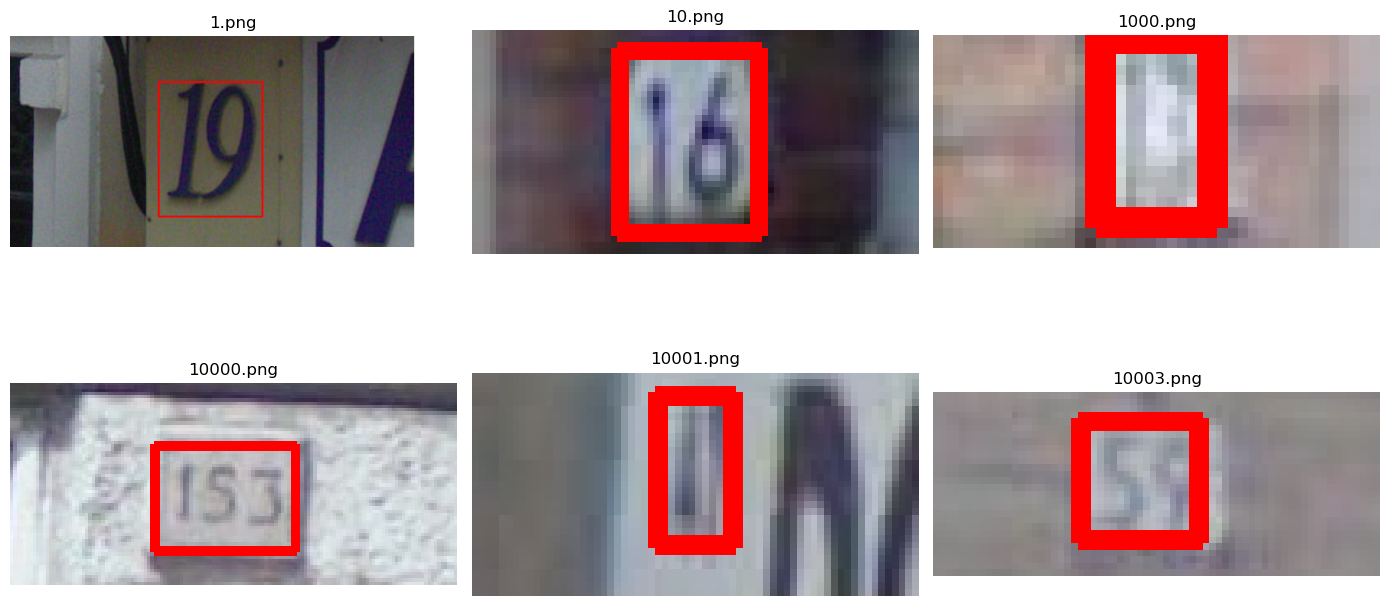

In [25]:
sample_paths = list((YOLO_DIR / "images" / "train").glob("*.png"))[:6]

plt.figure(figsize=(14, 8))

for i, img_path in enumerate(sample_paths, 1):
    label_path = YOLO_DIR / "labels" / "train" / f"{img_path.stem}.txt"

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path, "r", encoding="utf-8") as f:
        _, xc, yc, bw, bh = f.readline().strip().split()
        xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)
    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
MODEL_NAME = "yolov8s.pt"
IMG_SIZE = 768
EPOCHS = 15
BATCH = 16 if torch.cuda.is_available() else 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(yaml_path),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH,
    device=DEVICE,
    pretrained=True,
    project=str(ROOT / "runs"),
    name="svhn_number_detector",
    exist_ok=True,
    patience=10
)

Ultralytics 8.4.33  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\artem\Downloads\cv lab\data\svhn_yolo\svhn_number.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=svhn_number_detector, nbs=64, nms=False, opset=None, optimize

In [37]:
best_model_path = Path(train_results.save_dir) / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

metrics = best_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=IMG_SIZE,
    device=DEVICE
)

print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)
print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)

Ultralytics 8.4.33  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 48.446.3 MB/s, size: 36.8 KB)
val: Scanning C:\Users\artem\Downloads\cv lab\data\svhn_yolo\labels\test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 12.0it/s 1:08<0.1ss
                   all      13068      13068      0.916      0.892      0.931      0.553
Speed: 0.8ms preprocess, 1.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\artem\runs\detect\val2
mAP50 = 0.9314407631140841
mAP50-95 = 0.5533654996933822
Precision = 0.9156497000965942
Recall = 0.8921793694520967


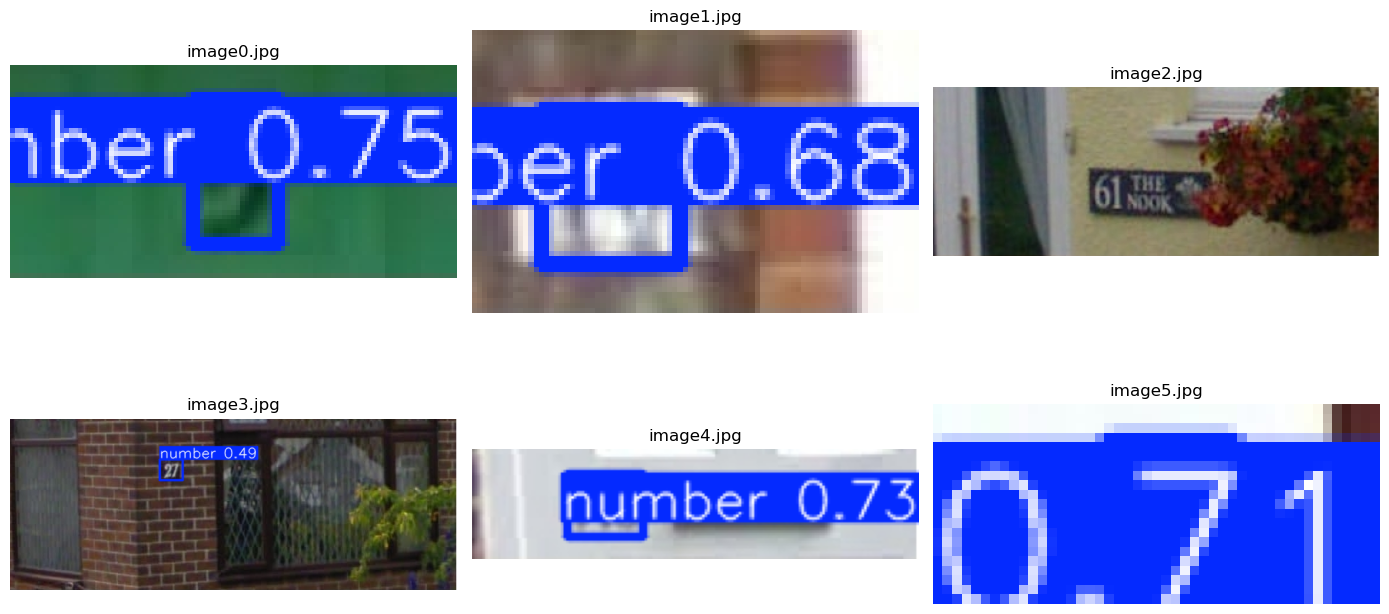

In [28]:
test_sample_paths = list((YOLO_DIR / "images" / "test").glob("*.png"))[:6]

results = best_model.predict(
    source=[str(p) for p in test_sample_paths],
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    verbose=False
)

plt.figure(figsize=(14, 8))

for i, result in enumerate(results, 1):
    img = result.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(Path(result.path).name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
MY_PHOTOS_DIR = ROOT / "my_street_photos"
MY_PHOTOS_DIR.mkdir(exist_ok=True)


In [35]:
my_results = best_model.predict(
    source=str(MY_PHOTOS_DIR),
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    save=True,
    project=str(ROOT / "runs"),
    name="my_street_predictions",
    exist_ok=True,
    verbose=False
)

print(ROOT / "runs" / "my_street_predictions")

Results saved to C:\Users\artem\Downloads\cv lab\runs\my_street_predictions
c:\Users\artem\Downloads\cv lab\runs\my_street_predictions


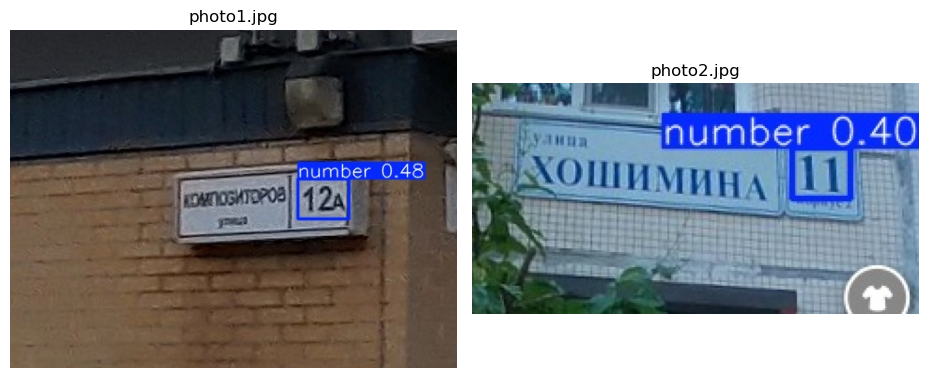

In [ ]:
pred_paths = sorted((ROOT / "runs" / "my_street_predictions").glob("*.*"))

n = min(6, len(pred_paths))
plt.figure(figsize=(14, 8))

for i, path in enumerate(pred_paths[:n], 1):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)

    plt.subplot((n + 2) // 3, 3, i)
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
print("Итоговые метрики:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"Лучшая модель: {best_model_path}")

Итоговые метрики:
mAP50: 0.9314
mAP50-95: 0.5534
Precision: 0.9156
Recall: 0.8922
Лучшая модель: C:\Users\artem\Downloads\cv lab\runs\svhn_number_detector\weights\best.pt
